In [29]:
import dadi
from dadi.Spectrum_mod import Spectrum
import numpy as np
import matplotlib.pyplot as plt
import dadi.Polyploidy.Integration as PolyInt

In [34]:
def auto_allo_he_comparison(T_div, T_WGD, H_vals = np.logspace(-5,1,7)):
    """
    T_div: time length of the divergence between diploid progenitors
    T_WGD: time ago (in diffusion units) of the WGD
    H_vals: list of population scaled HE rates
    """
    # first, let's just get an equilibrium SFS for autos
    # under a standard neutral model
    xx = dadi.Numerics.default_grid(pts=101)
    phi_auto = dadi.Polyploidy.PhiManip_supp.phi_1D_autotet(xx)
    sfs_auto = Spectrum.from_phi(1000*phi_auto, (40,), (xx,))

    # then, we will get an allo model without HEs by integrating
    # forward for a period of T_div followed by a period of T_WGD
    # (or, in effect, for a period of T_div + T_WGD)
    # but, we split the integration so we can reuse the SFS integrated 
    # for the divergence period for allos with HEs
    alloa_flag = dadi.Polyploidy.Integration.PloidyType.ALLOa
    allob_flag = dadi.Polyploidy.Integration.PloidyType.ALLOb

    phi_allo = dadi.PhiManip.phi_1D(xx)
    phi_allo = dadi.PhiManip.phi_1D_to_2D(xx, phi_allo)
    phi_allo = PolyInt.two_pops(phi_allo, xx, T_div, ploidyflag1=alloa_flag, ploidyflag2=allob_flag)
    phi_allo1 = PolyInt.two_pops(phi_allo, xx, T_WGD, ploidyflag1=alloa_flag, ploidyflag2=allob_flag)

    sfs_allo1 = Spectrum.from_phi(1000*phi_allo1, (20,20), (xx,xx))
    sfs_allo1 = sfs_allo1.combine_two_pops([0,1])
    
    print("Auto/Allo Comparison")
    dadi.Plotting.plot_1d_comp_Poisson(sfs_allo1, sfs_auto, show=True)

    # then, let's try to model the same thing with HEs
    for i, H in enumerate(H_vals):
        print(f"H = {H}")
    
        phi_allo2 = PolyInt.two_pops(phi_allo, xx, T_WGD, ploidyflag1=alloa_flag, ploidyflag2=allob_flag, m12=H, m21=H)

        sfs_allo2 = Spectrum.from_phi(1000*phi_allo2, (20,20), (xx,xx))
        sfs_allo2_collapsed = sfs_allo2.combine_two_pops([0,1])
    
        #print("Auto/HE Comparison")
        #dadi.Plotting.plot_1d_comp_Poisson(sfs_allo2_collapsed, sfs_auto, show=True)
        #dadi.Plotting.plot_1d_comp_Poisson(sfs_allo2_collapsed.fold(), sfs_auto.fold(), show=True)
        print("Allo/HE Comparison")
        dadi.Plotting.plot_1d_comp_Poisson(sfs_allo2_collapsed, sfs_allo1, show=True)
        #dadi.Plotting.plot_1d_comp_Poisson(sfs_allo2_collapsed.fold(), sfs_allo1.fold(), show=True)
        print("--------------------------------------------------------------------------------")
    

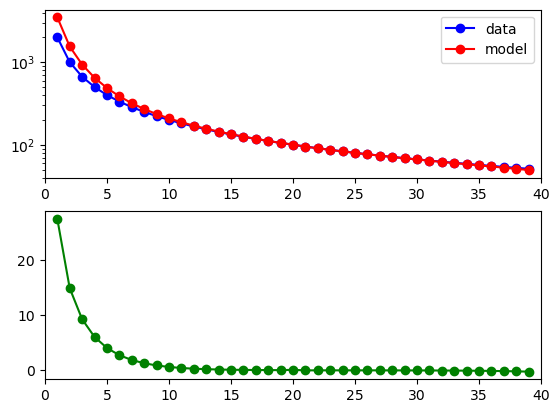

In [28]:
def dip_div_mig(T_div1, m1, T_div2, m2):
    xx = dadi.Numerics.default_grid(pts=101)
    phi_allo = dadi.PhiManip.phi_1D(xx)
    phi_allo = dadi.PhiManip.phi_1D_to_2D(xx, phi_allo)
    phi_allo = PolyInt.two_pops(phi_allo, xx, T_div1, m12=m1, m21=m1)

    sfs_allo = Spectrum.from_phi(1000*phi_allo, (20,20), (xx,xx))

    phi_allo = dadi.PhiManip.phi_1D(xx)
    phi_allo = dadi.PhiManip.phi_1D_to_2D(xx, phi_allo)
    phi_allo = PolyInt.two_pops(phi_allo, xx, T_div2, m12=m2, m21=m2)
    sfs_allo2 = Spectrum.from_phi(1000*phi_allo, (20,20), (xx,xx))
    dadi.Plotting.plot_2d_comp_Poisson(sfs_allo, sfs_allo2)

    sfs_collapsed = sfs_allo.combine_two_pops([0,1])
    sfs_collapsed2 = sfs_allo2.combine_two_pops([0,1])
    dadi.Plotting.plot_1d_comp_Poisson(sfs_collapsed, sfs_collapsed2)
    

# dip_div_mig(10, 10, 1, 10)
# dip_div_mig(10, 1, 1, 1)
# dip_div_mig(10, .1, 1, .1)

def allo_auto_comp(T_div1, m1):
    xx = dadi.Numerics.default_grid(pts=101)
    phi_allo = dadi.PhiManip.phi_1D(xx)
    phi_allo = dadi.PhiManip.phi_1D_to_2D(xx, phi_allo)
    phi_allo = PolyInt.two_pops(phi_allo, xx, T_div1, m12=m1, m21=m1)

    sfs_allo = Spectrum.from_phi(2000*phi_allo, (20,20), (xx,xx))

    sfs_collapsed = sfs_allo.combine_two_pops([0,1])

    phi_auto = dadi.Polyploidy.PhiManip_supp.phi_1D_autotet(xx)
    sfs_auto = Spectrum.from_phi(1000*phi_auto, (40,), (xx,))
    
    dadi.Plotting.plot_1d_comp_Poisson(sfs_collapsed, sfs_auto)

allo_auto_comp(.25, 0)

Auto/Allo Comparison


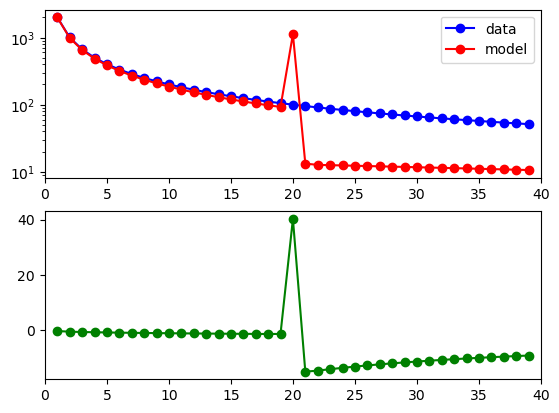

H = 1e-07
Allo/HE Comparison


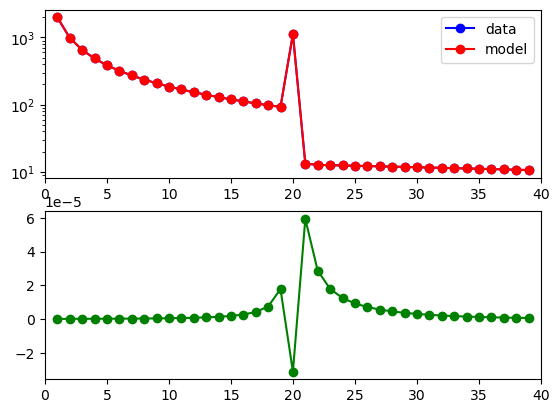

--------------------------------------------------------------------------------
H = 1e-06
Allo/HE Comparison


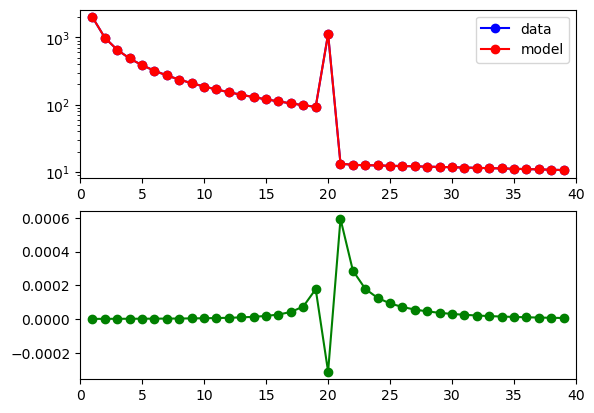

--------------------------------------------------------------------------------
H = 1e-05
Allo/HE Comparison


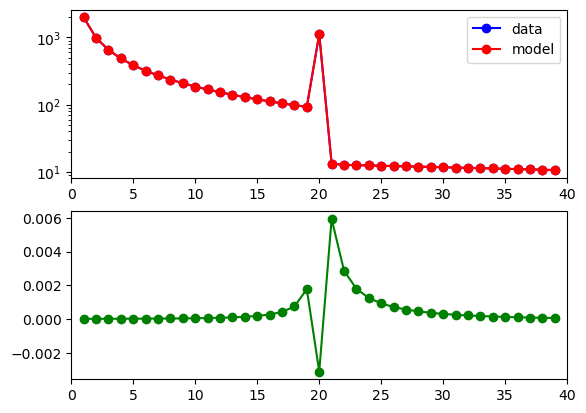

--------------------------------------------------------------------------------
H = 0.0001
Allo/HE Comparison


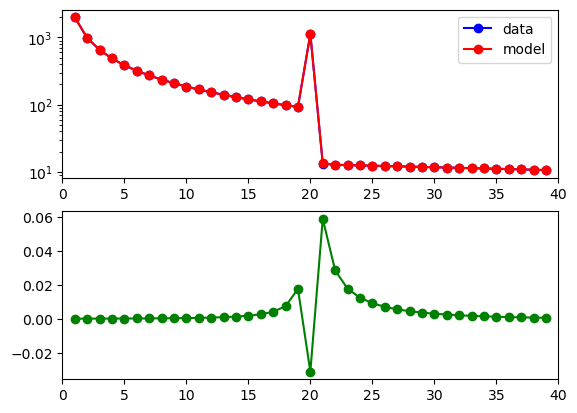

--------------------------------------------------------------------------------
H = 0.001
Allo/HE Comparison


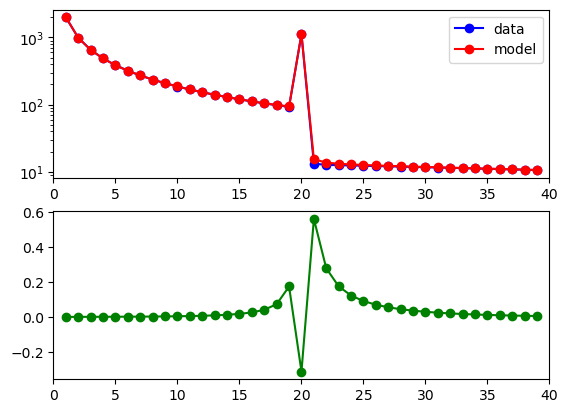

--------------------------------------------------------------------------------
H = 0.01
Allo/HE Comparison


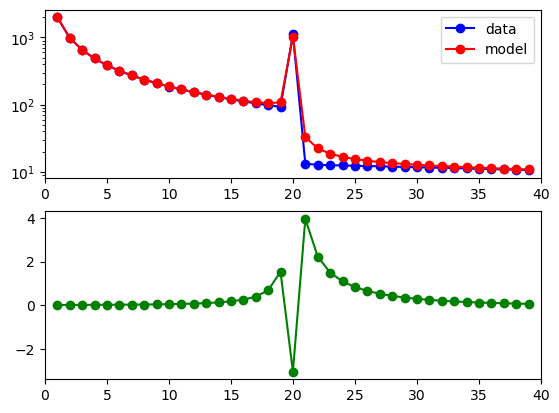

--------------------------------------------------------------------------------
H = 0.1
Allo/HE Comparison


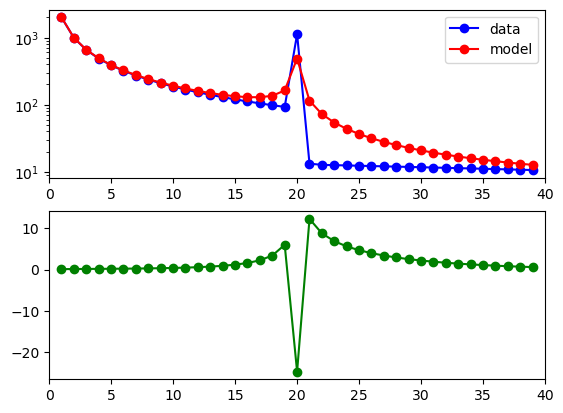

--------------------------------------------------------------------------------
H = 1.0
Allo/HE Comparison


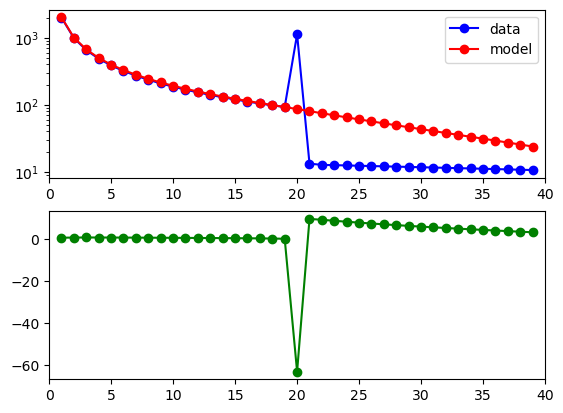

--------------------------------------------------------------------------------
H = 10.0
Allo/HE Comparison


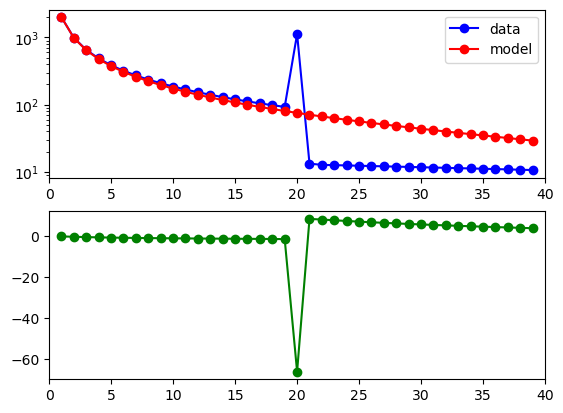

--------------------------------------------------------------------------------


In [35]:
auto_allo_he_comparison(T_div=1, T_WGD=1, H_vals = np.logspace(-7,1,9))

Auto/Allo Comparison


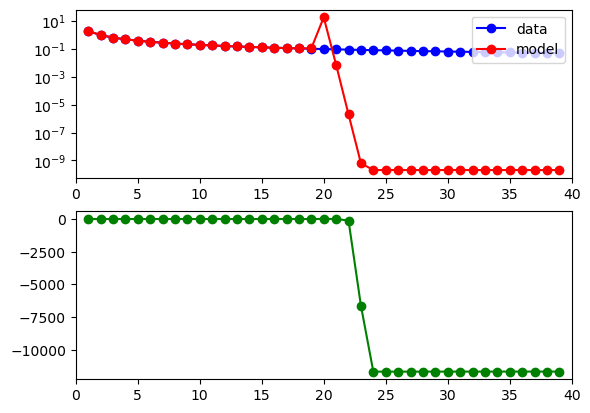

H = 1e-05
Auto/HE Comparison


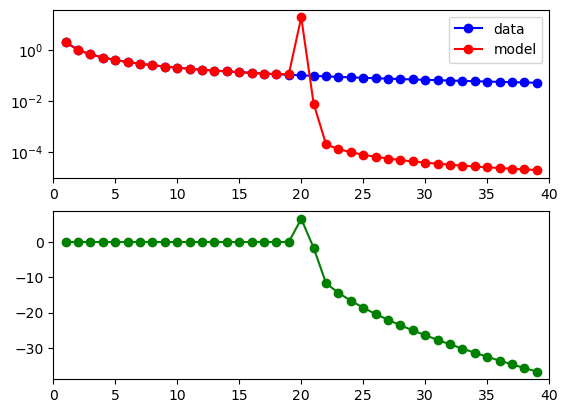

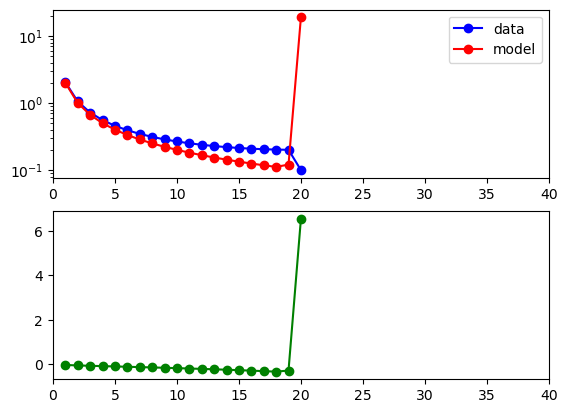

Allo/HE Comparison


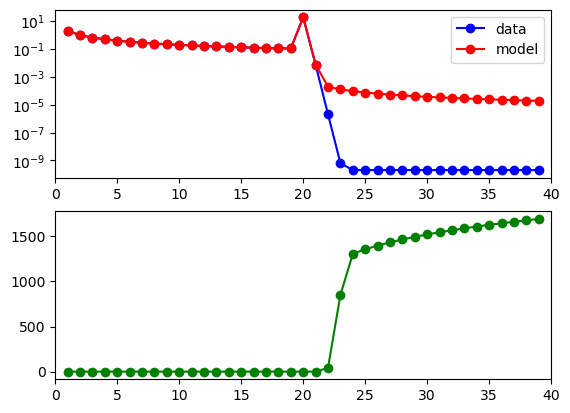

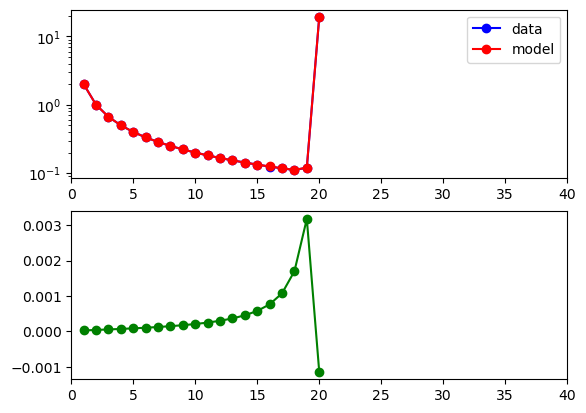

--------------------------------------------------------------------------------
H = 0.0001
Auto/HE Comparison


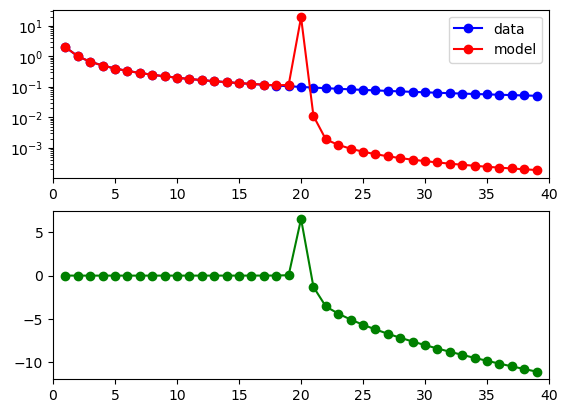

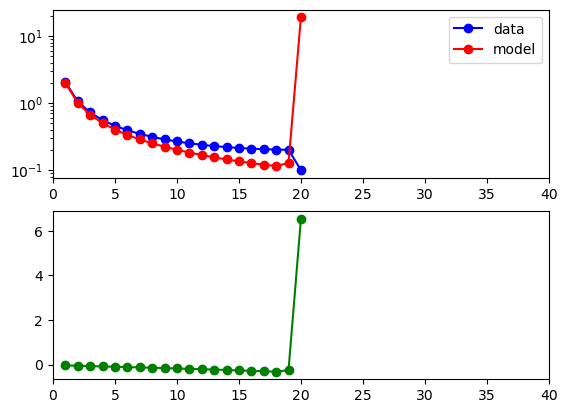

Allo/HE Comparison


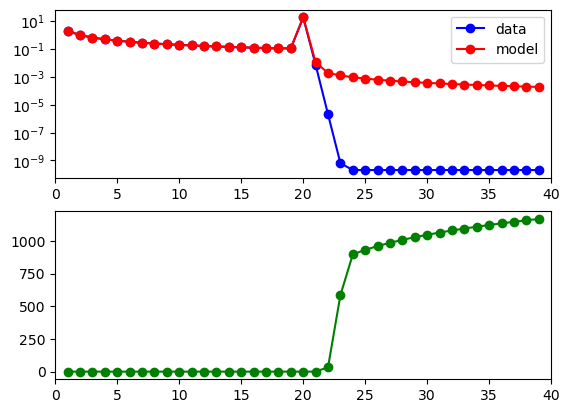

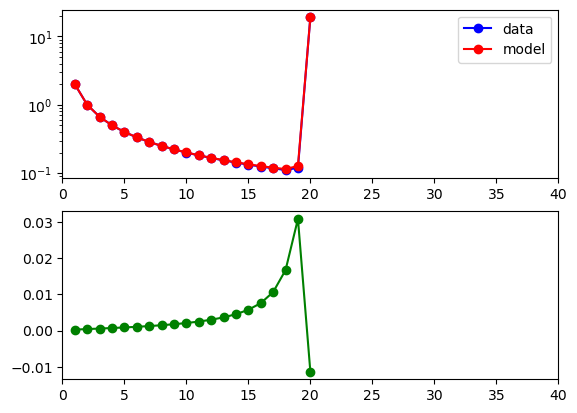

--------------------------------------------------------------------------------
H = 0.001
Auto/HE Comparison


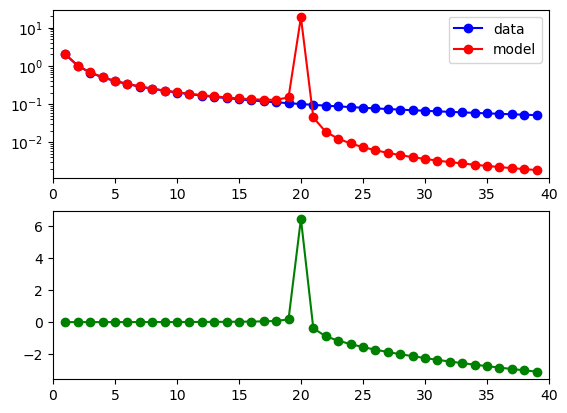

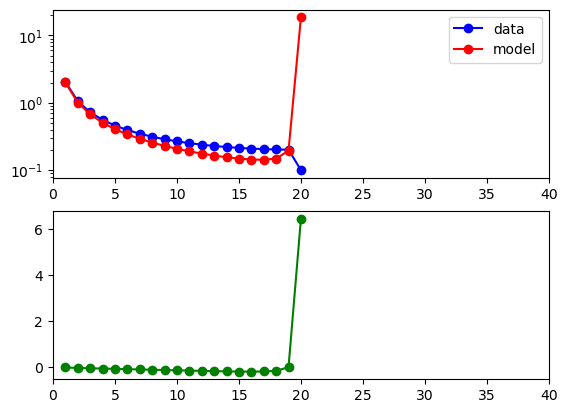

Allo/HE Comparison


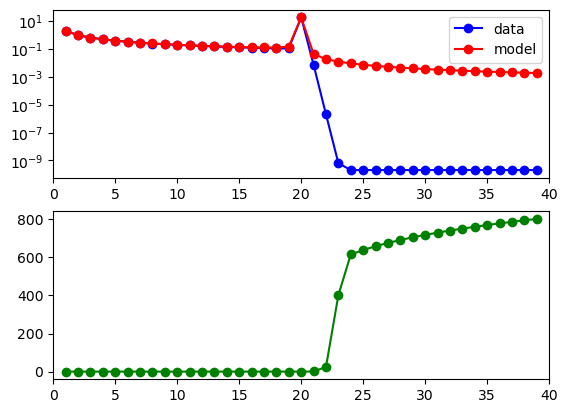

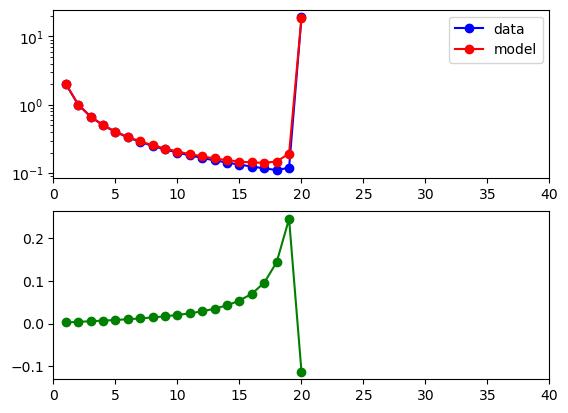

--------------------------------------------------------------------------------
H = 0.01
Auto/HE Comparison


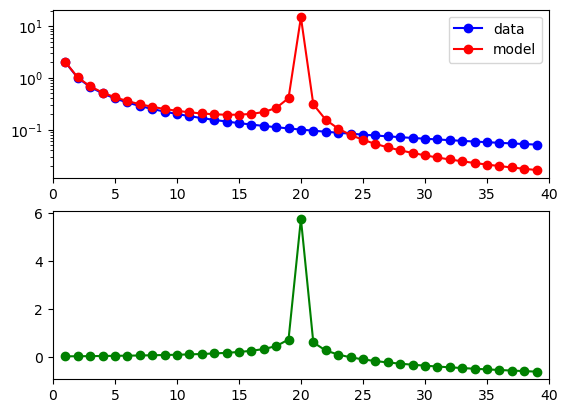

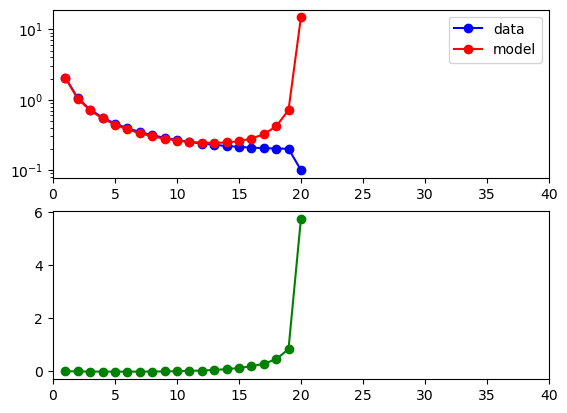

Allo/HE Comparison


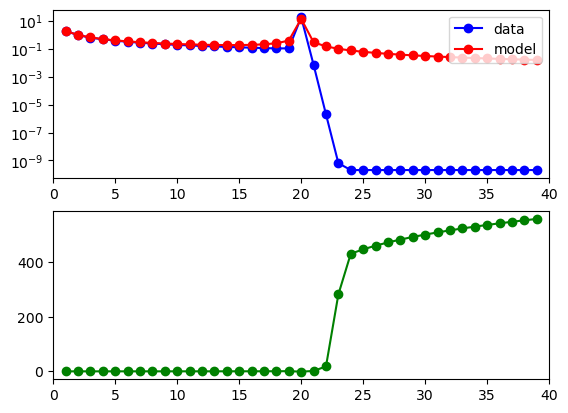

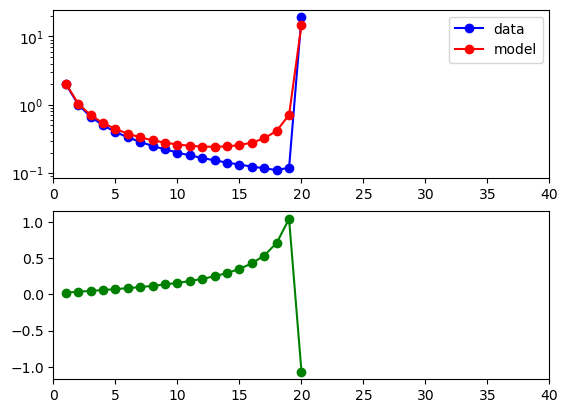

--------------------------------------------------------------------------------
H = 0.1
Auto/HE Comparison


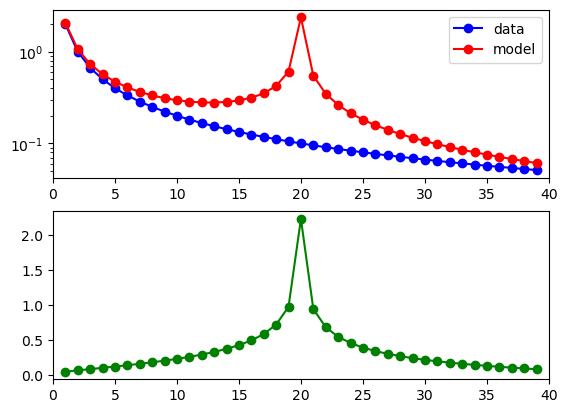

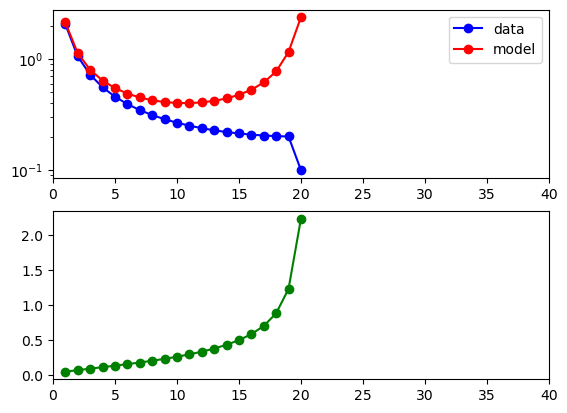

Allo/HE Comparison


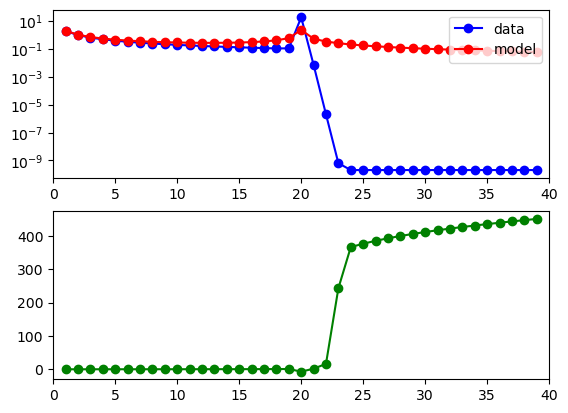

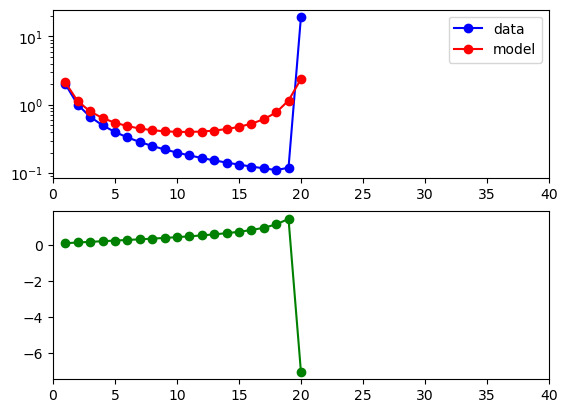

--------------------------------------------------------------------------------
H = 1.0
Auto/HE Comparison


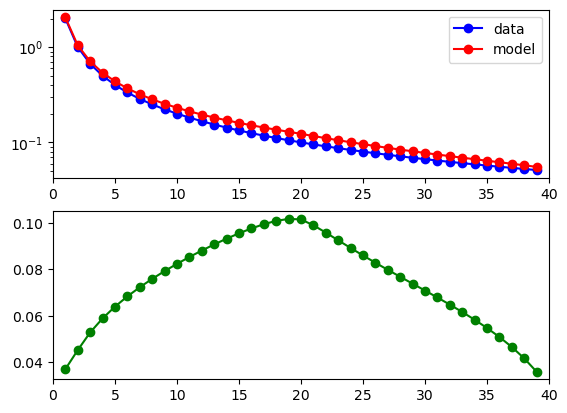

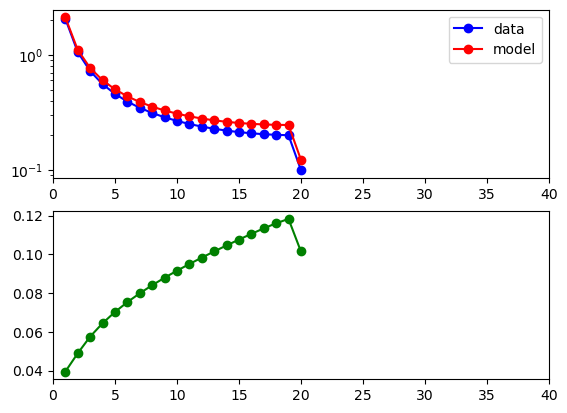

Allo/HE Comparison


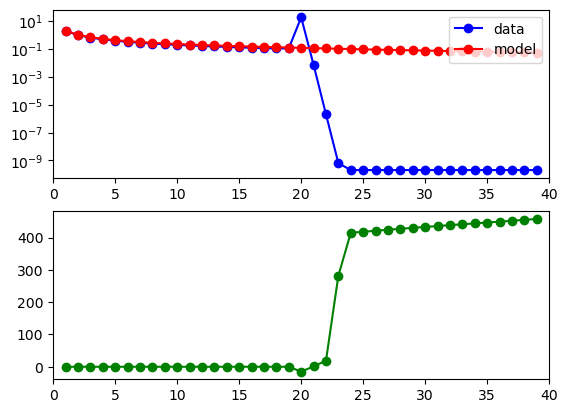

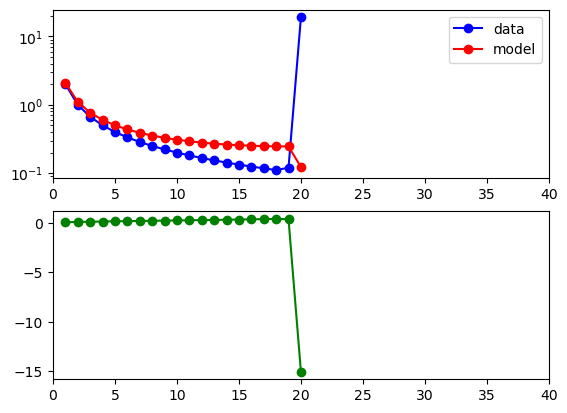

--------------------------------------------------------------------------------
H = 10.0
Auto/HE Comparison


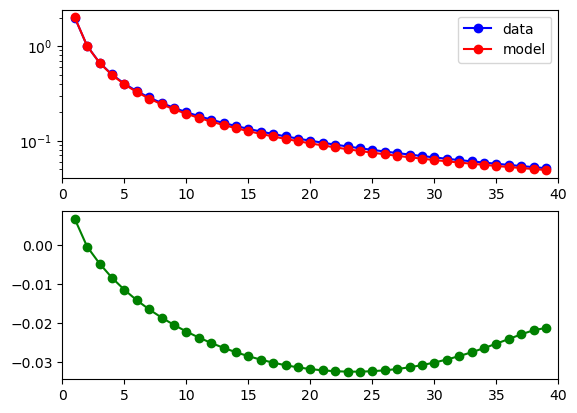

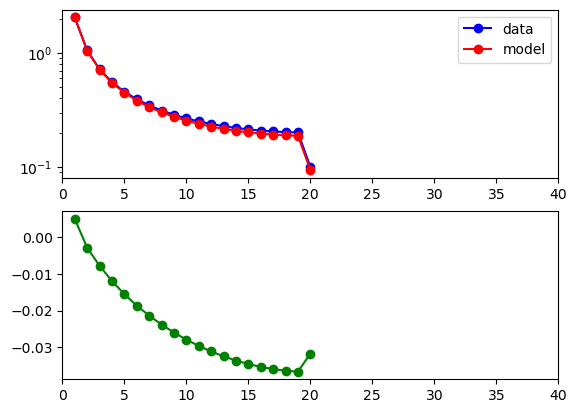

Allo/HE Comparison


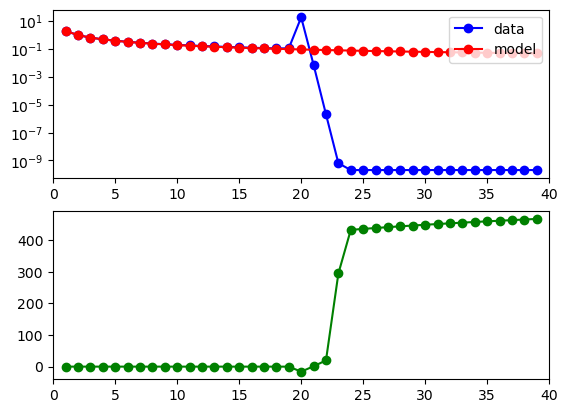

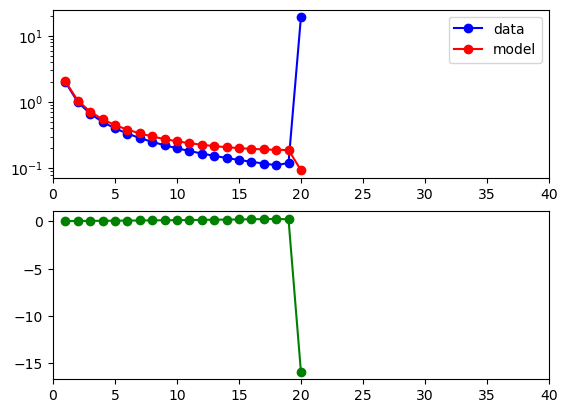

--------------------------------------------------------------------------------


In [8]:
auto_allo_he_comparison(T_div=10, T_WGD=10)

Auto/Allo Comparison


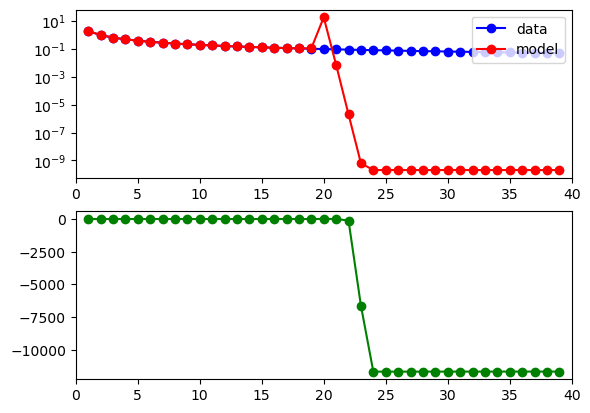

H = 100
Auto/HE Comparison


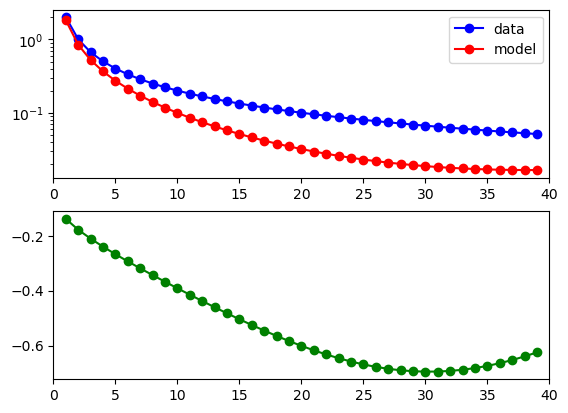

Allo/HE Comparison


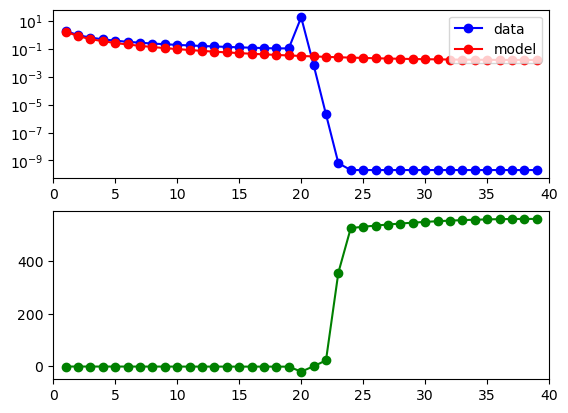

--------------------------------------------------------------------------------


In [61]:
auto_allo_he_comparison(T_div=10, T_WGD=10, H_vals=[100])

Auto/Allo Comparison


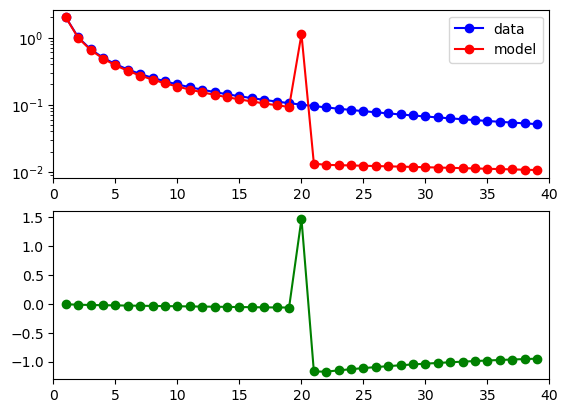

H = 0.1
Auto/HE Comparison


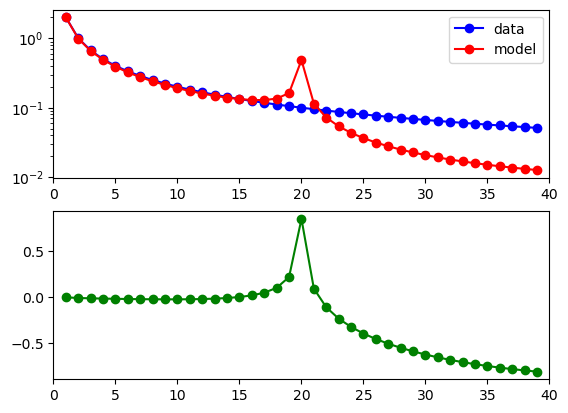

Allo/HE Comparison


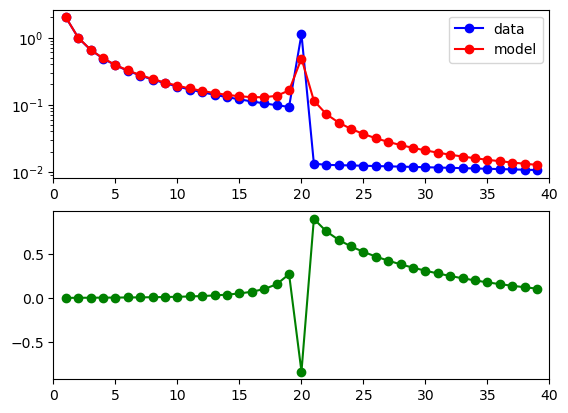

--------------------------------------------------------------------------------
Auto/Allo Comparison


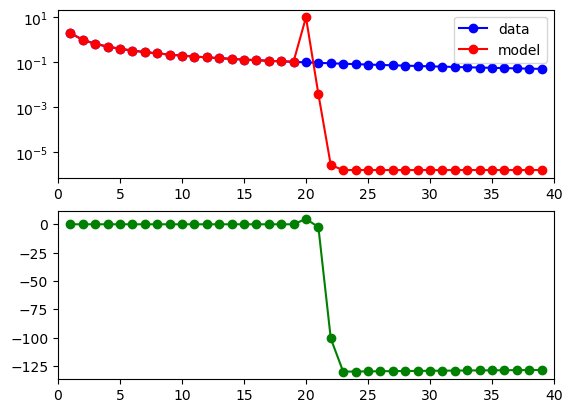

H = 0.1
Auto/HE Comparison


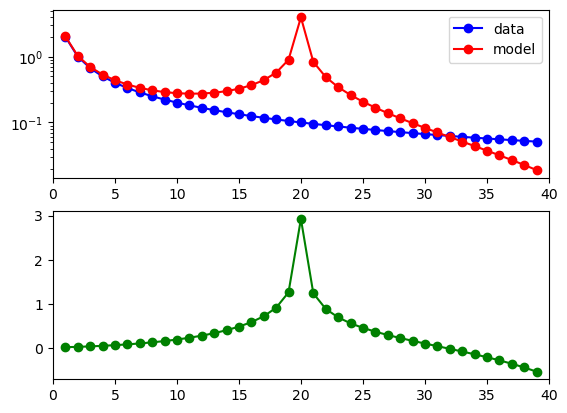

Allo/HE Comparison


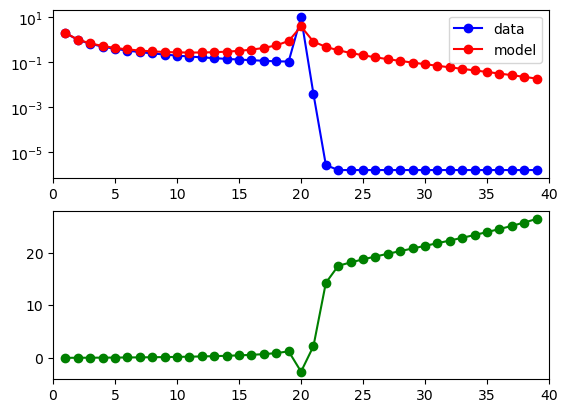

--------------------------------------------------------------------------------
Auto/Allo Comparison


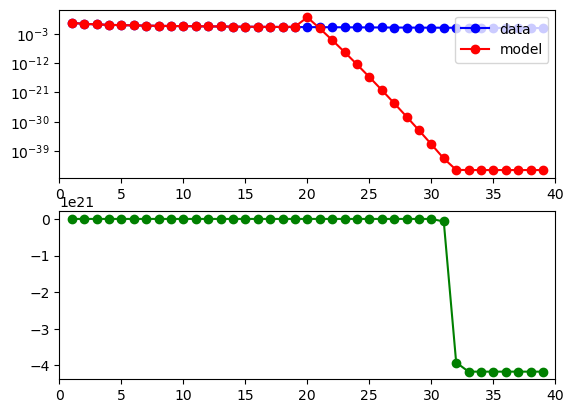

H = 0.1
Auto/HE Comparison


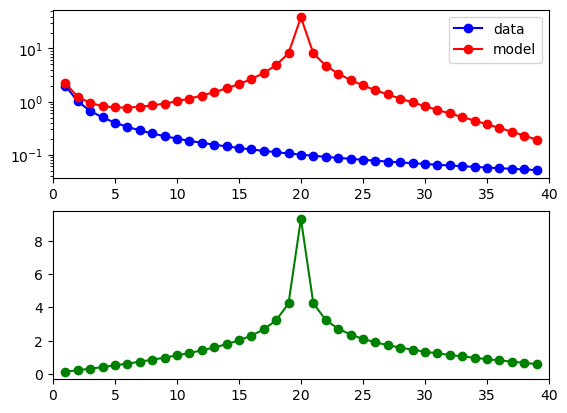

Allo/HE Comparison


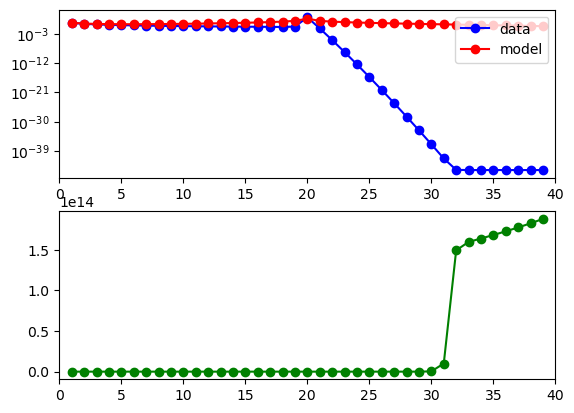

--------------------------------------------------------------------------------


In [72]:
auto_allo_he_comparison(T_div=1, T_WGD=1, H_vals=[.1])
auto_allo_he_comparison(T_div=10, T_WGD=1, H_vals=[.1])
auto_allo_he_comparison(T_div=100, T_WGD=1, H_vals=[.1])

Auto/Allo Comparison


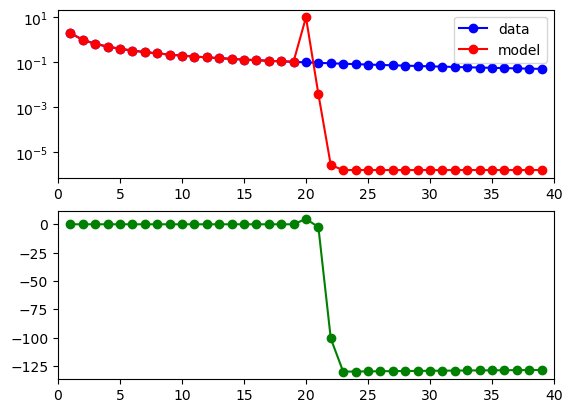

H = 10
Auto/HE Comparison


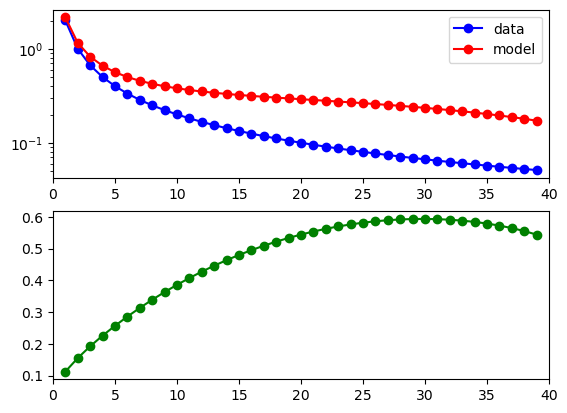

Allo/HE Comparison


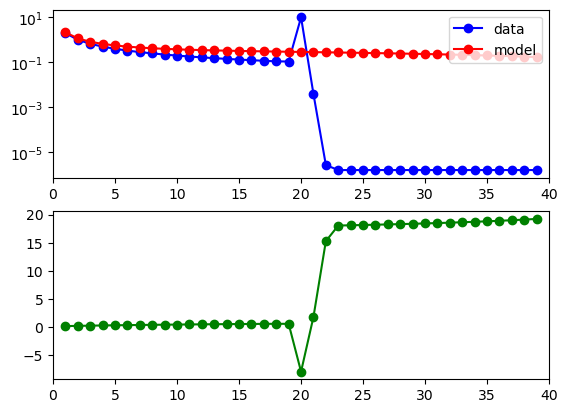

--------------------------------------------------------------------------------
Auto/Allo Comparison


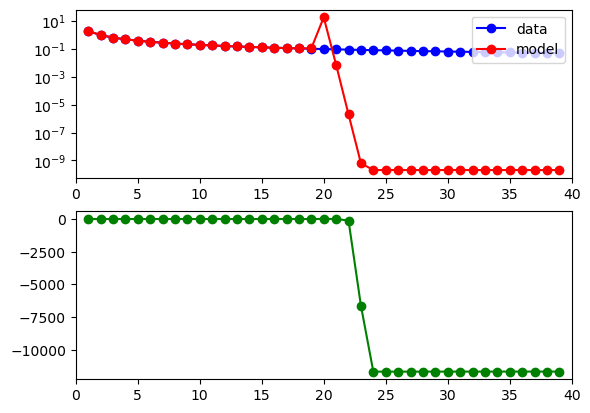

H = 10
Auto/HE Comparison


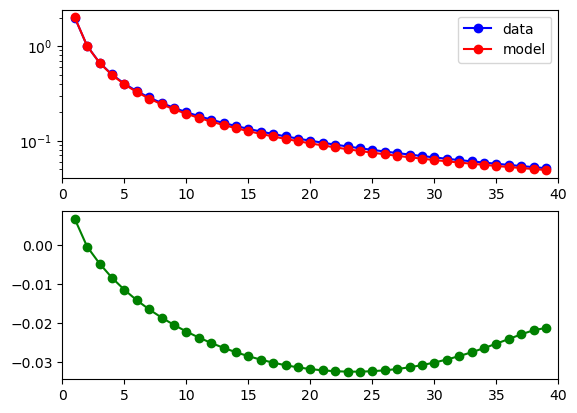

Allo/HE Comparison


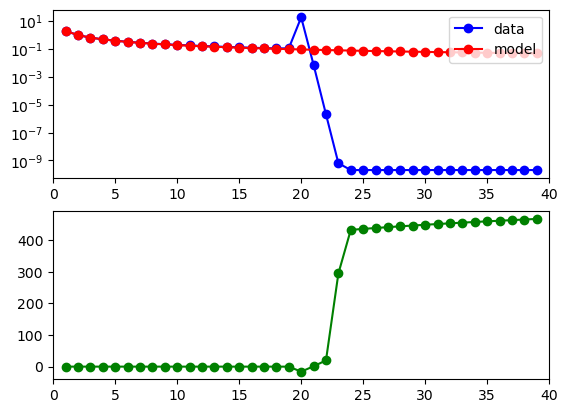

--------------------------------------------------------------------------------


In [77]:
auto_allo_he_comparison(T_div=10, T_WGD=1, H_vals=[10])
auto_allo_he_comparison(T_div=10, T_WGD=10, H_vals=[10])

Auto/Allo Comparison


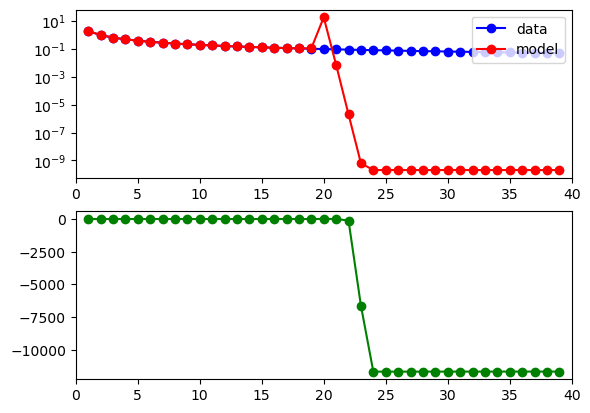

Auto/HE Comparison


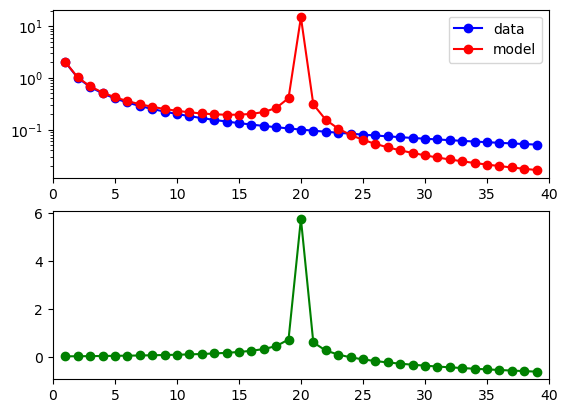

Allo/HE Comparison


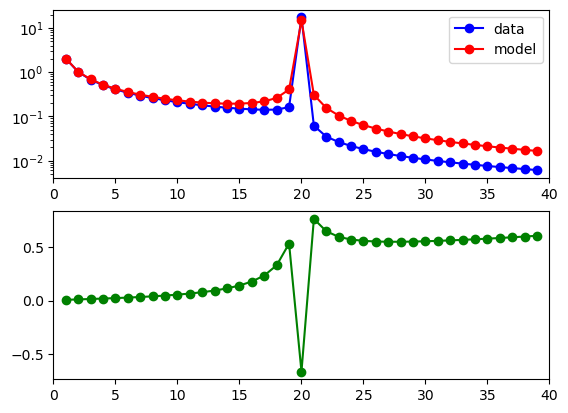

In [87]:
T_div = 10
T_WGD = 10
H = .1
# first, let's just get an equilibrium SFS for autos
# under a standard neutral model
xx = dadi.Numerics.default_grid(pts=101)
phi_auto = dadi.Polyploidy.PhiManip_supp.phi_1D_autotet(xx)
sfs_auto = dadi.Spectrum.from_phi(phi_auto, (40,), (xx,))
sfs_auto_folded = sfs_auto.fold()

# then, we will get an allo model without HEs by integrating
# forward for a period of T_div followed by a period of T_WGD
# (or, in effect, for a period of T_div + T_WGD)
# but, we split the integration so we can reuse the SFS integrated 
# for the divergence period for allos with HEs
alloa_flag = dadi.Polyploidy.Integration.PloidyType.ALLOa
allob_flag = dadi.Polyploidy.Integration.PloidyType.ALLOb

phi_allo = dadi.PhiManip.phi_1D(xx)
phi_allo = dadi.PhiManip.phi_1D_to_2D(xx, phi_allo)
phi_allo = PolyInt.two_pops(phi_allo, xx, T_div, ploidyflag1=alloa_flag, ploidyflag2=allob_flag)
phi_allo1 = PolyInt.two_pops(phi_allo, xx, T_WGD, ploidyflag1=alloa_flag, ploidyflag2=allob_flag)

sfs_allo1 = dadi.Spectrum.from_phi(phi_allo1, (20,20), (xx,xx))
sfs_allo1_collapsed = sfs_allo1.combine_two_pops([0,1])
    
print("Auto/Allo Comparison")
dadi.Plotting.plot_1d_comp_Poisson(sfs_allo1_collapsed, sfs_auto, show=True)

# then, let's try to model the same thing with HEs
# full HE rate
phi_allo2 = PolyInt.two_pops(phi_allo, xx, T_WGD, ploidyflag1=alloa_flag, ploidyflag2=allob_flag, m12=H, m21=H)
sfs_allo2 = dadi.Spectrum.from_phi(phi_allo2, (20,20), (xx,xx))
sfs_allo2_collapsed = sfs_allo2.combine_two_pops([0,1])

# halved HE rate
phi_allo3 = PolyInt.two_pops(phi_allo, xx, T_WGD, ploidyflag1=alloa_flag, ploidyflag2=allob_flag, m12=H/10, m21=H/10)
sfs_allo3 = dadi.Spectrum.from_phi(phi_allo3, (20,20), (xx,xx))
sfs_allo3_collapsed = sfs_allo3.combine_two_pops([0,1])

# averaged SFS
sfs_allo_avg = .9*sfs_allo1_collapsed + .1*sfs_allo2_collapsed

print("Auto/HE Comparison")
dadi.Plotting.plot_1d_comp_Poisson(sfs_allo3_collapsed, sfs_auto, show=True)
#dadi.Plotting.plot_1d_comp_Poisson(sfs_allo3_collapsed.fold(), sfs_auto_folded, show=True)
print("Allo/HE Comparison")
dadi.Plotting.plot_1d_comp_Poisson(sfs_allo3_collapsed, sfs_allo_avg, show=True)
#dadi.Plotting.plot_1d_comp_Poisson(sfs_allo3_collapsed.fold(), sfs_allo_avg.fold(), show=True)
  